In [84]:
import itertools

import sympy as sy
import numpy as np

In [85]:
import fitz

Tamanho dos vetores

In [86]:
from utils import plot_pdf

In [87]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This example will not work for different vector sizes.

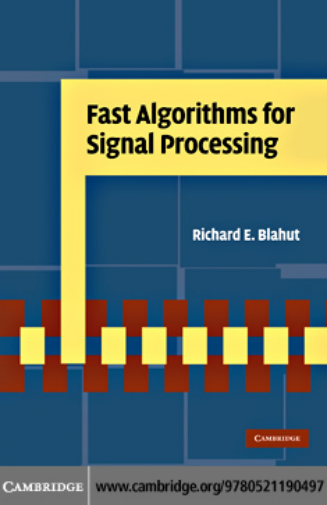

In [88]:
plot_pdf(doc[0], dpi=100)

In [89]:
d_num = 3
g_num = 2

Vetor de exemplo

In [90]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))

Grau do polinômio

In [91]:
d_degree = d_num - 1
g_degree = g_num - 1

In [92]:
x = sy.symbols("x")

In [93]:
# sy.factor(x**4-1)

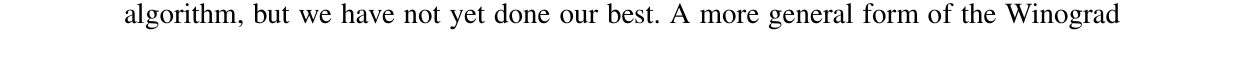

In [94]:
plot_pdf(doc[177], [.91, .94])

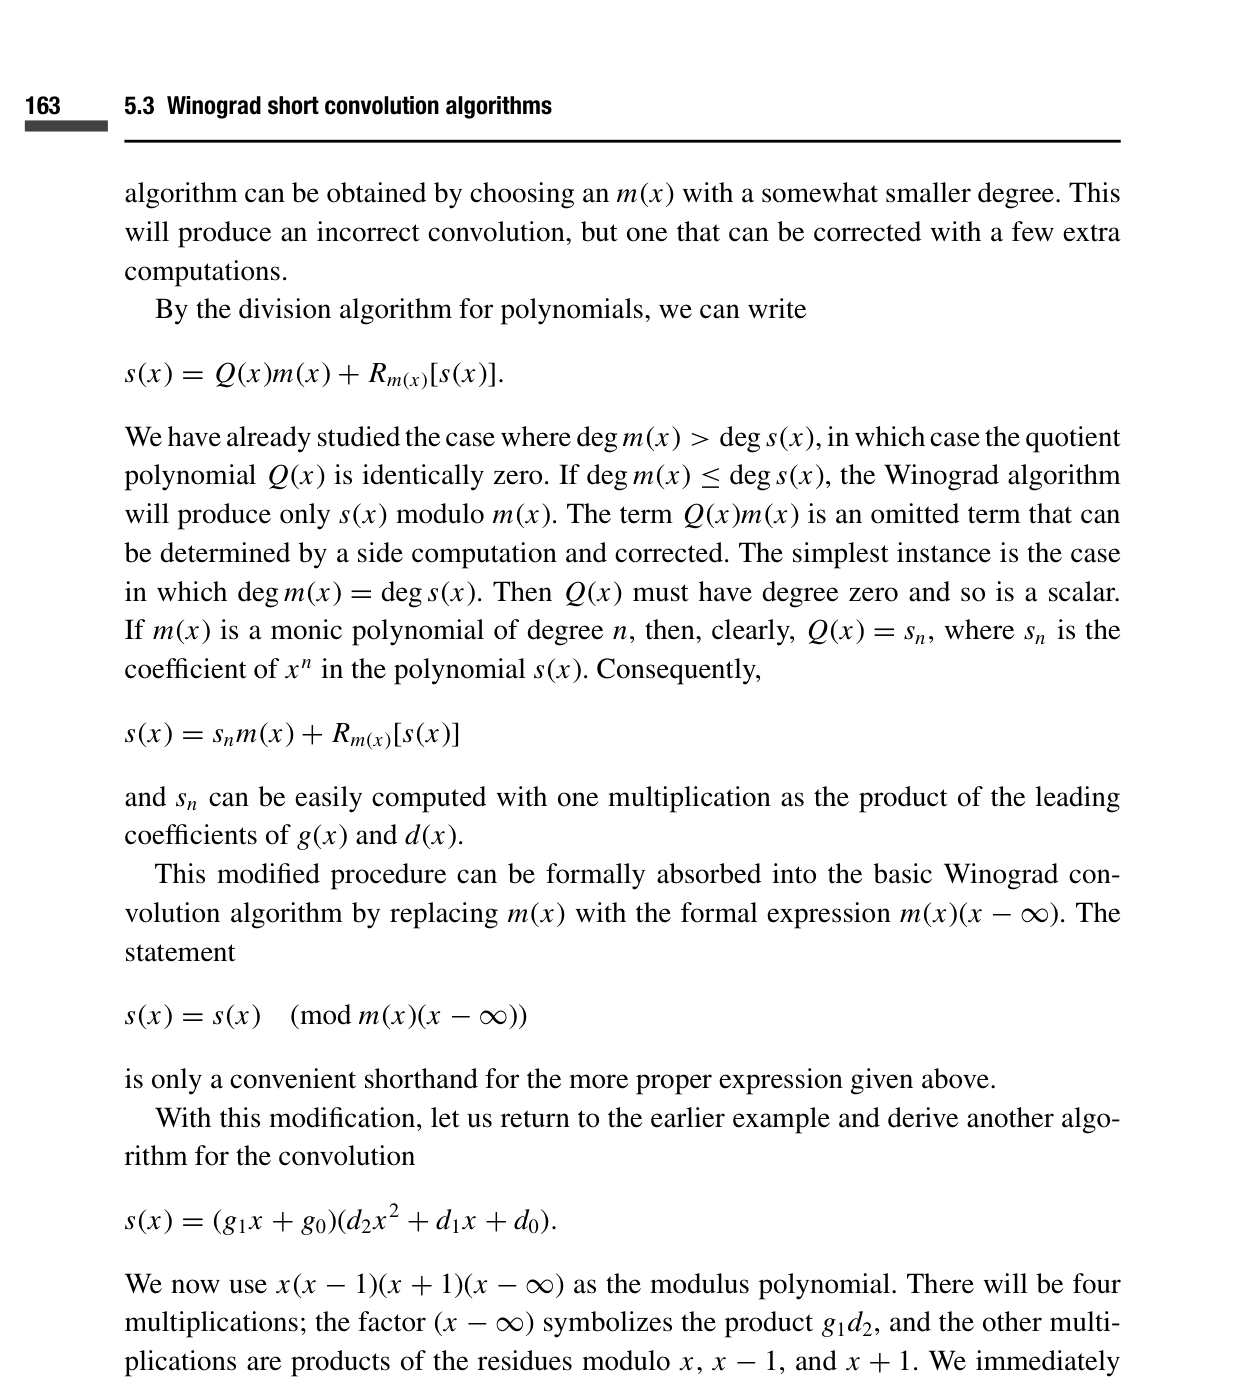

In [95]:
plot_pdf(doc[178], [0, .731])

Total of residues

In [96]:
d_degree + g_degree

3

In [ ]:
# mk0 = [x + i*r for r in range(1, d_degree + g_degree - 1) for i in [-1, 1]]
# mk = sy.Matrix(([x] + mk0)[:d_degree + g_degree])

In [97]:
mk = sy.Matrix([x, x - 1, x + 1])
mk

Matrix([
[    x],
[x - 1],
[x + 1]])

In [98]:
di = sy.Matrix(sy.symbols(" ".join(f"d{i}"for i in range(d_num))))
di

Matrix([
[d0],
[d1],
[d2]])

In [99]:
gi = sy.Matrix(sy.symbols(" ".join(f"g{i}"for i in range(g_num))))
gi

Matrix([
[g0],
[g1]])

In [100]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

d0 + d1*x + d2*x**2

In [101]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

g0 + g1*x

In [102]:
sx = gx*dx
sx

(g0 + g1*x)*(d0 + d1*x + d2*x**2)

In [103]:
gk_ = [sy.div(gx, q, domain ='QQ')[1] for q in mk]
gk = sy.Matrix(gk_ + [gx.args[-1].args[0]])
gk

Matrix([
[     g0],
[g0 + g1],
[g0 - g1],
[     g1]])

In [104]:
dk_ = [sy.div(dx, q, domain ='QQ')[1] for q in mk]
dk = sy.Matrix(dk_ + [dx.args[-1].args[0]])
dk

Matrix([
[          d0],
[d0 + d1 + d2],
[d0 - d1 + d2],
[          d2]])

In [105]:
mmk_ = [sy.expand(np.prod(d)) for d in itertools.combinations(reversed(mk), len(mk)-1)]
mmk = sy.Matrix(mmk_ + [sy.expand(np.prod(mk))])
mmk

Matrix([
[x**2 - 1],
[x**2 + x],
[x**2 - x],
[x**3 - x]])

Pegando quociente e resto, agora tem q colocar no formato nm+NM=1

In [106]:
mx_div = [sy.div(dv, ds, domain ='QQ') for dv, ds in zip(mmk, mk)]
mx_div

[(x, -1), (x + 2, 2), (x - 2, 2)]

Multiplicar o resto pela matriz G depois
o sinal negativo vai pra matriz G e não pra C

In [107]:
nnk = sy.Matrix([1/z[1] for z in mx_div])
nnk

Matrix([
[ -1],
[1/2],
[1/2]])

In [108]:
nk = sy.Matrix([q[0]*r*(-1) for q, r in zip(mx_div, nnk)])
nk

Matrix([
[       x],
[-x/2 - 1],
[ 1 - x/2]])

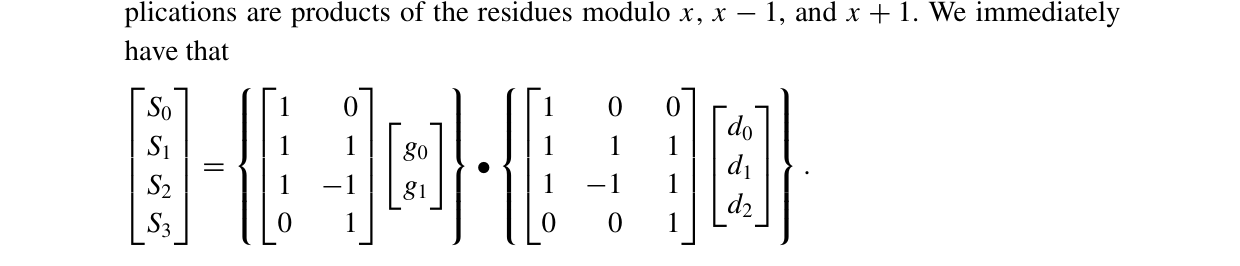

In [109]:
plot_pdf(doc[178], [.71, .85])

In [110]:
a_mtx = sy.Matrix([[d.coeff(c, 1) for c in di] for d in dk])
a_mtx

Matrix([
[1,  0, 0],
[1,  1, 1],
[1, -1, 1],
[0,  0, 1]])

In [111]:
bg_mtx = sy.diag(*([g*r for g, r in zip(gk.flat(), nnk.flat()+[1])]))
bg_mtx

Matrix([
[-g0,           0,           0,  0],
[  0, g0/2 + g1/2,           0,  0],
[  0,           0, g0/2 - g1/2,  0],
[  0,           0,           0, g1]])

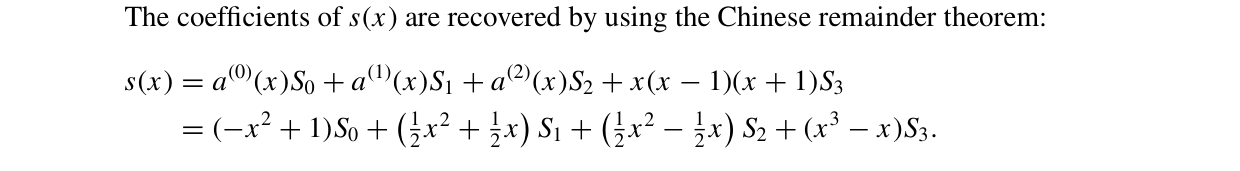

In [112]:
plot_pdf(doc[178], [.85, .94])

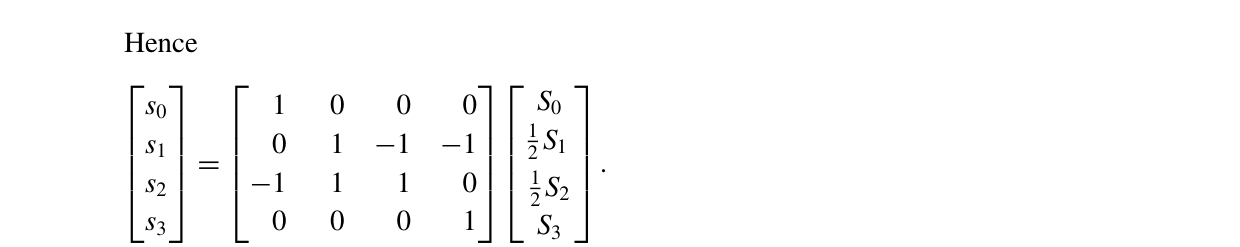

In [113]:
plot_pdf(doc[179], [.25, .38])

In [114]:
c_mtx = sy.Matrix([[d.coeff(x, c) for d in mmk] for c in range(len(np.prod(mk).as_poly().all_coeffs()))])
c_mtx

Matrix([
[-1, 0,  0,  0],
[ 0, 1, -1, -1],
[ 1, 1,  1,  0],
[ 0, 0,  0,  1]])

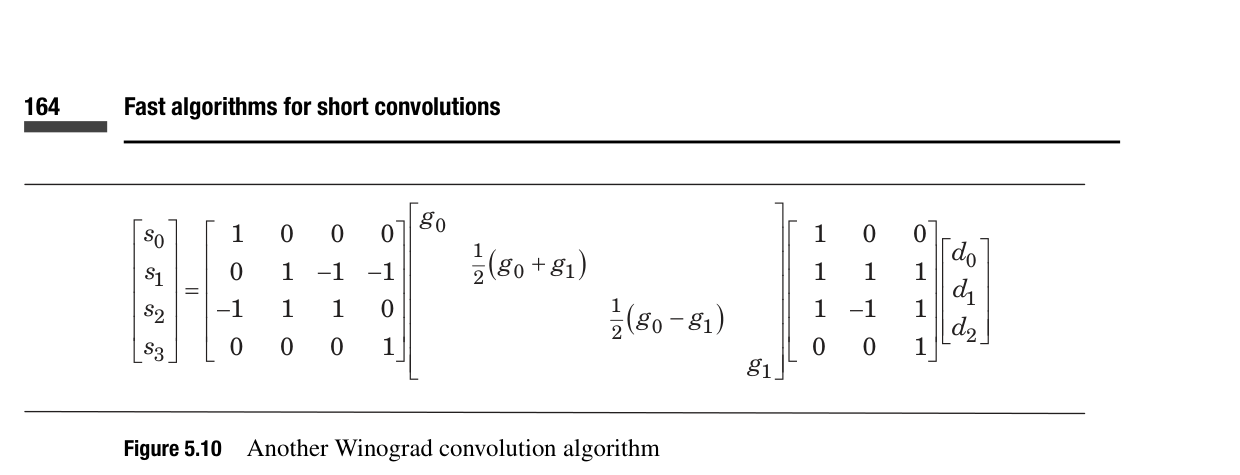

In [115]:
plot_pdf(doc[179], [0, .25])

In [116]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di))
s

Matrix([
[-1, 0,  0,  0],
[ 0, 1, -1, -1],
[ 1, 1,  1,  0],
[ 0, 0,  0,  1]])*Matrix([
[-g0,           0,           0,  0],
[  0, g0/2 + g1/2,           0,  0],
[  0,           0, g0/2 - g1/2,  0],
[  0,           0,           0, g1]])*Matrix([
[1,  0, 0],
[1,  1, 1],
[1, -1, 1],
[0,  0, 1]])*Matrix([
[d0],
[d1],
[d2]])

In [117]:
subs = {k: v for k, v in zip(di.flat()+gi.flat(), d_values + g_values)}
subs

{d0: 1, d1: 2, d2: 3, g0: 1, g1: 2}

In [118]:
si = s.subs(subs)
si

Matrix([
[-1, 0,  0,  0],
[ 0, 1, -1, -1],
[ 1, 1,  1,  0],
[ 0, 0,  0,  1]])*Matrix([
[-1,   0,    0, 0],
[ 0, 3/2,    0, 0],
[ 0,   0, -1/2, 0],
[ 0,   0,    0, 2]])*Matrix([
[1,  0, 0],
[1,  1, 1],
[1, -1, 1],
[0,  0, 1]])*Matrix([
[1],
[2],
[3]])

In [119]:
sy.expand(sx)

d0*g0 + d0*g1*x + d1*g0*x + d1*g1*x**2 + d2*g0*x**2 + d2*g1*x**3

Let's compare the output polynomial matrix from direct and winograd method

In [120]:
sy.Matrix(np.convolve(np.array(di).reshape(-1), np.array(gi).reshape(-1)))

Matrix([
[        d0*g0],
[d0*g1 + d1*g0],
[d1*g1 + d2*g0],
[        d2*g1]])

In [121]:
se = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di), evaluate=True)
se

Matrix([
[        d0*g0],
[d0*g1 + d1*g0],
[d1*g1 + d2*g0],
[        d2*g1]])

Comparing numerical outputs from direct and winograd method

In [122]:
sy.Matrix(np.convolve(d_values, g_values))

Matrix([
[1],
[4],
[7],
[6]])

In [123]:
se.subs(subs)

Matrix([
[1],
[4],
[7],
[6]])